# 01 — Surface Code Exploration with Stim

This notebook validates the Week 1 quantum simulation modules:
1. Circuit generation and sampling (`surface_code.py`)
2. Syndrome reshaping and visualization (`syndrome.py`)
3. MWPM baseline decoding (`decoder_baseline.py`)
4. **Threshold validation**: MWPM logical error rates match literature (~1% threshold)

In [2]:
import sys
from pathlib import Path

# Add project root to path so 'src' is importable
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from src.quantum.surface_code import (
    SurfaceCodeParams,
    generate_circuit,
    analyze_circuit_structure,
    get_qubit_layout,
)
from src.quantum.syndrome import (
    SyndromeGrid,
    compute_syndrome_diff,
    get_syndrome_statistics,
    visualize_syndrome,
    visualize_syndrome_spacetime,
)
from src.quantum.decoder_baseline import MWPMDecoder, run_sinter_benchmark

%matplotlib inline
plt.rcParams.update({'font.size': 12, 'figure.figsize': (8, 6), 'savefig.dpi': 150})

## 1. Circuit Generation

Generate rotated surface code circuits for d=3, 5, 7 with standard depolarizing noise.

In [3]:
NOISE_PARAMS = {
    "after_clifford_depolarization": 0.01,
    "before_round_data_depolarization": 0.01,
    "before_measure_flip_probability": 0.01,
    "after_reset_flip_probability": 0.01,
}

circuits = {}
for d in [3, 5, 7]:
    params = SurfaceCodeParams(distance=d, rounds=d)
    circuits[d] = generate_circuit(params, NOISE_PARAMS)
    print(f"d={d}: {circuits[d].num_detectors} detectors, "
          f"{circuits[d].num_observables} observables, "
          f"{circuits[d].circuit.num_qubits} qubits")

d=3: 24 detectors, 1 observables, 26 qubits
d=5: 120 detectors, 1 observables, 64 qubits
d=7: 336 detectors, 1 observables, 118 qubits


### Circuit Structure Analysis

In [4]:
rows = []
for d in [3, 5, 7]:
    info = analyze_circuit_structure(circuits[d])
    rows.append({
        "distance": d,
        "qubits": info["num_qubits"],
        "data_qubits": info["num_data_qubits"],
        "stabilizers": info["num_stabilizers"],
        "detectors": info["num_detectors"],
        "DEM_errors": info["num_error_mechanisms"],
    })

df_structure = pd.DataFrame(rows)
df_structure

,distance,qubits,data_qubits,stabilizers,detectors,DEM_errors
0,3,26,9,8,24,286
1,5,64,25,24,120,1953
2,7,118,49,48,336,6602


## 2. Syndrome Sampling & Reshaping

Sample syndromes and reshape them from flat detector arrays to spatial grids.

In [5]:
# Sample from d=3 circuit
sc3 = circuits[3]
syndromes, observables = sc3.sample(shots=1000, seed=42)
print(f"Syndromes shape: {syndromes.shape}")
print(f"Observables shape: {observables.shape}")
print(f"Mean syndrome weight: {syndromes.sum(axis=1).mean():.2f}")
print(f"Observable flip rate: {observables.mean():.4f}")

Syndromes shape: (1000, 24)
Observables shape: (1000, 1)
Mean syndrome weight: 2.67
Observable flip rate: 0.1770


In [6]:
# Reshape to spatial grids
sg3 = SyndromeGrid(sc3.circuit)
print(f"Grid shape: rounds={sg3.rounds}, h={sg3.grid_h}, w={sg3.grid_w}")

grids = sg3.reshape_batch(syndromes)
print(f"Batch grid shape: {grids.shape}")

Grid shape: rounds=4, h=4, w=4
Batch grid shape: (1000, 4, 4, 4)


### Syndrome Visualization

Visualize example syndromes for d=3 and d=5.

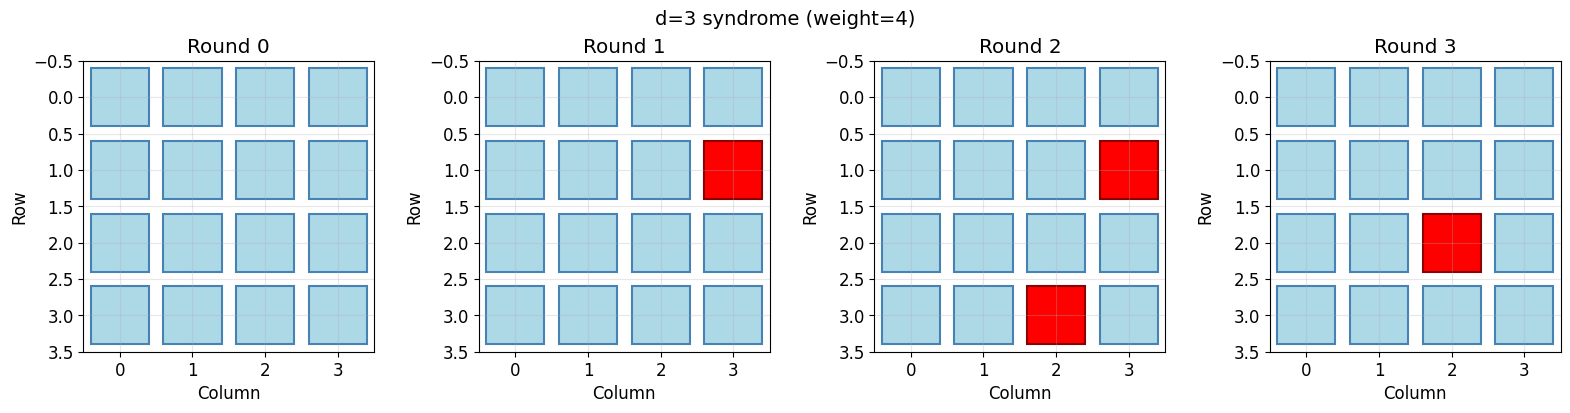

In [7]:
# Find a syndrome with some triggered detectors for a good visualization
weights = syndromes.sum(axis=1)
interesting_idx = np.argmax(weights > 3)

fig, axes = plt.subplots(1, min(sg3.rounds, 4), figsize=(4 * min(sg3.rounds, 4), 4))
grid_single = sg3.reshape_single(syndromes[interesting_idx])
for r in range(min(sg3.rounds, 4)):
    visualize_syndrome(grid_single, distance=3, round_idx=r, ax=axes[r],
                       title=f"Round {r}")
fig.suptitle(f"d=3 syndrome (weight={int(weights[interesting_idx])})", fontsize=14)
plt.tight_layout()
plt.show()

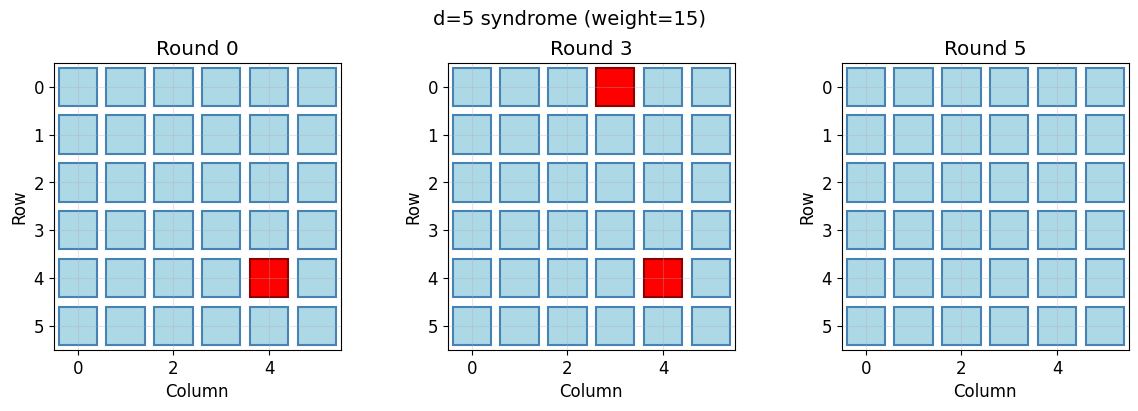

In [8]:
# Visualize d=5
sc5 = circuits[5]
sg5 = SyndromeGrid(sc5.circuit)
syn5, _ = sc5.sample(shots=100, seed=42)
weights5 = syn5.sum(axis=1)
idx5 = np.argmax(weights5 > 5)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
grid5 = sg5.reshape_single(syn5[idx5])
for i, r in enumerate([0, sg5.rounds // 2, sg5.rounds - 1]):
    visualize_syndrome(grid5, distance=5, round_idx=r, ax=axes[i],
                       title=f"Round {r}")
fig.suptitle(f"d=5 syndrome (weight={int(weights5[idx5])})", fontsize=14)
plt.tight_layout()
plt.show()

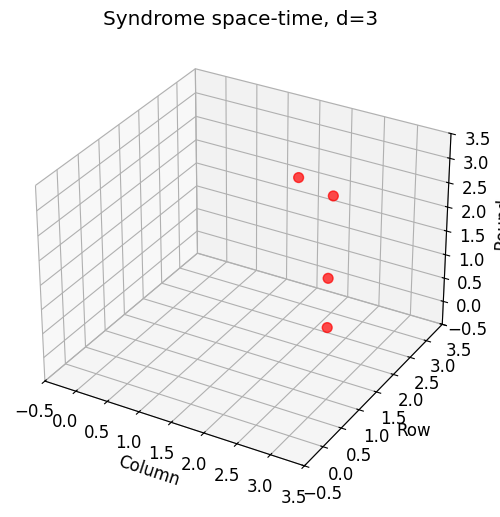

In [9]:
# Space-time visualization
visualize_syndrome_spacetime(grid_single, distance=3)
plt.show()

### Syndrome Statistics

In [10]:
for d in [3, 5, 7]:
    sc = circuits[d]
    sg = SyndromeGrid(sc.circuit)
    syn, _ = sc.sample(shots=5000, seed=42)
    stats = get_syndrome_statistics(syn, sg)
    print(f"d={d}: detection_fraction={stats['detection_fraction']:.4f}, "
          f"mean_weight={stats['mean_syndrome_weight']:.2f} +/- {stats['std_syndrome_weight']:.2f}")

d=3: detection_fraction=0.1102, mean_weight=2.64 +/- 2.07
d=5: detection_fraction=0.1293, mean_weight=15.52 +/- 5.24
d=7: detection_fraction=0.1375, mean_weight=46.20 +/- 9.19


## 3. MWPM Decoding

Evaluate the MWPM decoder at p=0.01 for d=3, 5, 7 and verify that larger distance gives lower error rate.

In [11]:
for d in [3, 5, 7]:
    sc = circuits[d]
    decoder = MWPMDecoder.from_surface_code_circuit(sc)
    syn, obs = sc.sample(shots=10_000, seed=42)
    results = decoder.evaluate(syn, obs)
    print(f"d={d}: LER={results['logical_error_rate']:.5f} "
          f"[{results['ci_lower']:.5f}, {results['ci_upper']:.5f}] "
          f"({results['num_errors']}/{results['num_shots']} errors)")

d=3: LER=0.06110 [0.05648, 0.06597] (611/10000 errors)
d=5: LER=0.08420 [0.07883, 0.08981] (842/10000 errors)
d=7: LER=0.10640 [0.10042, 0.11261] (1064/10000 errors)


## 4. Threshold Estimation

Sweep physical error rate and plot logical error rate vs. physical error rate for d=3, 5, 7.
The threshold is where the curves for different distances cross (~0.7-1% for depolarizing noise).

In [12]:
distances = [3, 5, 7]
error_rates = np.array([0.001, 0.002, 0.003, 0.005, 0.007, 0.01, 0.015, 0.02, 0.03, 0.05, 0.07, 0.1])
NUM_SHOTS = 10_000

results = []

for d in distances:
    for p in error_rates:
        noise = {
            "after_clifford_depolarization": p,
            "before_round_data_depolarization": p,
            "before_measure_flip_probability": p,
            "after_reset_flip_probability": p,
        }
        params = SurfaceCodeParams(distance=d, rounds=d)
        sc = generate_circuit(params, noise)
        decoder = MWPMDecoder.from_surface_code_circuit(sc)
        syn, obs = sc.sample(shots=NUM_SHOTS, seed=42)
        res = decoder.evaluate(syn, obs)
        results.append({
            "distance": d,
            "physical_error_rate": p,
            **res,
        })
        print(f"d={d}, p={p:.4f}: LER={res['logical_error_rate']:.5f}")

df_threshold = pd.DataFrame(results)
df_threshold

d=3, p=0.0010: LER=0.00030
d=3, p=0.0020: LER=0.00280
d=3, p=0.0030: LER=0.00600
d=3, p=0.0050: LER=0.01570
d=3, p=0.0070: LER=0.03600
d=3, p=0.0100: LER=0.05370
d=3, p=0.0150: LER=0.11840
d=3, p=0.0200: LER=0.17240
d=3, p=0.0300: LER=0.27400
d=3, p=0.0500: LER=0.44060
d=3, p=0.0700: LER=0.49030
d=3, p=0.1000: LER=0.49220
d=5, p=0.0010: LER=0.00020
d=5, p=0.0020: LER=0.00120
d=5, p=0.0030: LER=0.00310
d=5, p=0.0050: LER=0.01430
d=5, p=0.0070: LER=0.03390
d=5, p=0.0100: LER=0.08650
d=5, p=0.0150: LER=0.19430
d=5, p=0.0200: LER=0.30720
d=5, p=0.0300: LER=0.42940
d=5, p=0.0500: LER=0.49650
d=5, p=0.0700: LER=0.50120
d=5, p=0.1000: LER=0.49920
d=7, p=0.0010: LER=0.00000
d=7, p=0.0020: LER=0.00020
d=7, p=0.0030: LER=0.00130
d=7, p=0.0050: LER=0.01110
d=7, p=0.0070: LER=0.03130
d=7, p=0.0100: LER=0.10600
d=7, p=0.0150: LER=0.27160
d=7, p=0.0200: LER=0.39380
d=7, p=0.0300: LER=0.49880
d=7, p=0.0500: LER=0.50180
d=7, p=0.0700: LER=0.50600
d=7, p=0.1000: LER=0.50280


,distance,physical_error_rate,logical_error_rate,ci_lower,ci_upper,num_errors,num_shots
0,3,0.001,0.0003,0.000062,0.000876,3,10000
1,3,0.002,0.0028,0.001861,0.004044,28,10000
2,3,0.003,0.0060,0.004582,0.007717,60,10000
3,3,0.005,0.0157,0.013355,0.018332,157,10000
4,3,0.007,0.0360,0.032434,0.039839,360,10000
5,3,0.010,0.0537,0.049362,0.058300,537,10000
6,3,0.015,0.1184,0.112130,0.124894,1184,10000
7,3,0.020,0.1724,0.165043,0.179948,1724,10000
8,3,0.030,0.2740,0.265275,0.282857,2740,10000
9,3,0.050,0.4406,0.430838,0.450397,4406,10000


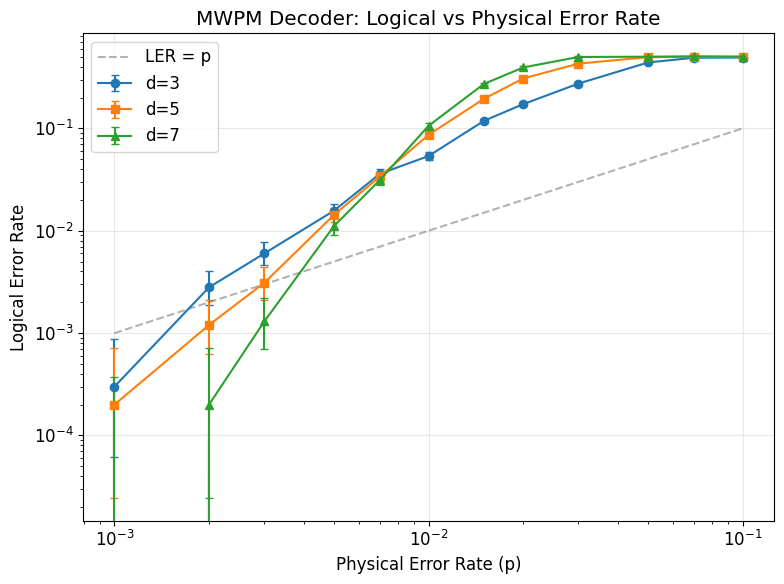

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = {3: 'tab:blue', 5: 'tab:orange', 7: 'tab:green'}
markers = {3: 'o', 5: 's', 7: '^'}

for d in distances:
    mask = df_threshold['distance'] == d
    sub = df_threshold[mask]
    ax.errorbar(
        sub['physical_error_rate'],
        sub['logical_error_rate'],
        yerr=[sub['logical_error_rate'] - sub['ci_lower'],
              sub['ci_upper'] - sub['logical_error_rate']],
        fmt=f'{markers[d]}-',
        color=colors[d],
        label=f'd={d}',
        capsize=3,
        markersize=6,
    )

# Reference line: logical = physical
p_range = np.logspace(-3, -1, 100)
ax.plot(p_range, p_range, 'k--', alpha=0.3, label='LER = p')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Physical Error Rate (p)')
ax.set_ylabel('Logical Error Rate')
ax.set_title('MWPM Decoder: Logical vs Physical Error Rate')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/mwpm_threshold.png', dpi=150)
plt.show()

## 5. Syndrome Diff Visualization

The temporal difference between consecutive syndrome rounds highlights where new errors occurred.

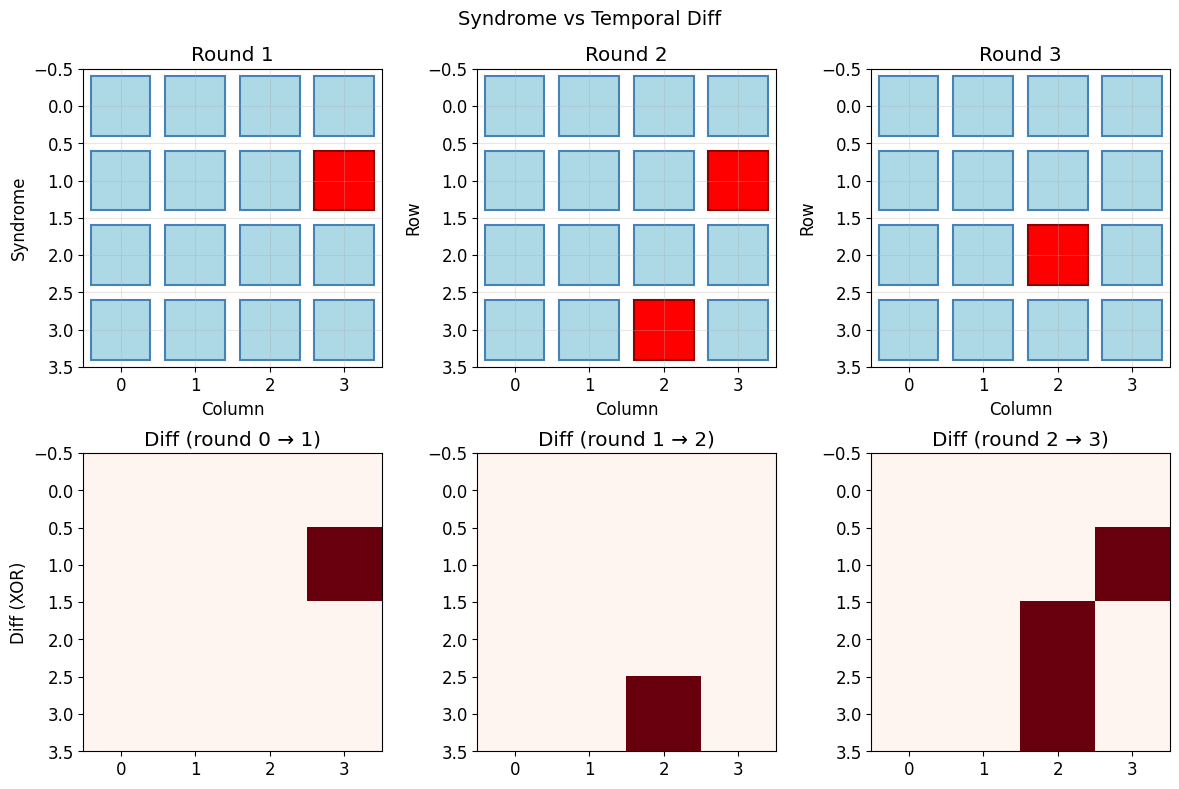

In [14]:
# Show original vs diff syndromes
grid_example = sg3.reshape_single(syndromes[interesting_idx])
diff_example = compute_syndrome_diff(grid_example)

fig, axes = plt.subplots(2, min(3, sg3.rounds - 1), figsize=(12, 8))
n_show = min(3, sg3.rounds - 1)
for i in range(n_show):
    visualize_syndrome(grid_example, distance=3, round_idx=i+1, ax=axes[0, i],
                       title=f"Round {i+1}")
    # Plot diff manually
    axes[1, i].imshow(diff_example[i], cmap='Reds', vmin=0, vmax=1,
                      interpolation='nearest')
    axes[1, i].set_title(f"Diff (round {i} → {i+1})")

axes[0, 0].set_ylabel('Syndrome')
axes[1, 0].set_ylabel('Diff (XOR)')
fig.suptitle('Syndrome vs Temporal Diff', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Noise Rate Comparison

Compare syndrome statistics at different physical error rates.

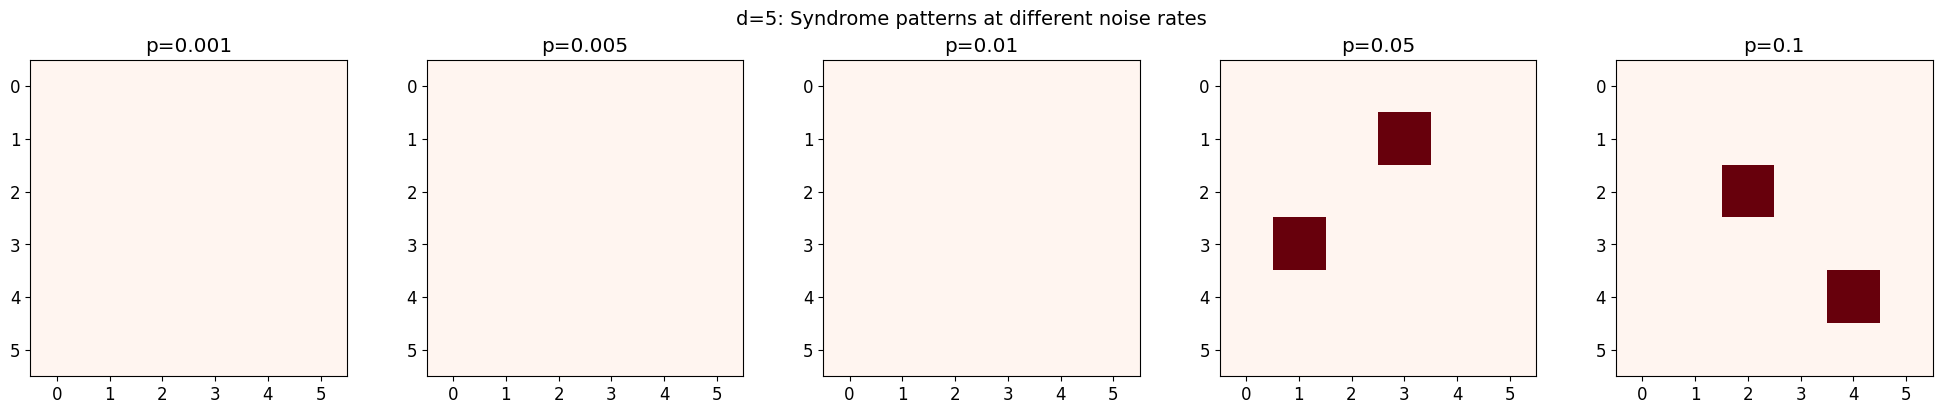

In [15]:
d = 5
test_rates = [0.001, 0.005, 0.01, 0.05, 0.1]

fig, axes = plt.subplots(1, len(test_rates), figsize=(4 * len(test_rates), 4))

for i, p in enumerate(test_rates):
    noise = {"after_clifford_depolarization": p}
    params = SurfaceCodeParams(distance=d, rounds=d)
    sc = generate_circuit(params, noise)
    sg = SyndromeGrid(sc.circuit)
    syn, _ = sc.sample(shots=100, seed=42)
    
    # Show the first sample, first round
    grid = sg.reshape_single(syn[0])
    axes[i].imshow(grid[0], cmap='Reds', vmin=0, vmax=1, interpolation='nearest')
    axes[i].set_title(f'p={p}')
    axes[i].set_aspect('equal')

fig.suptitle(f'd={d}: Syndrome patterns at different noise rates', fontsize=14)
plt.tight_layout()
plt.show()